<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_KiDS_Pgk_DomainBoundaryGradient_V6_DOWNLOAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM KiDS Pgk Domain-Boundary Gradient V6 — DOWNLOAD notebook

Clean self-contained V6 notebook.

It adds the missing ECSM domain-boundary-gradient term:

\[
D_{\rm ECSM}=G_{\rm lens/source}\times B_{\rm lens}\times |\nabla \chi_{\rm domain}|
\]

Guardrail: this is still a projection-bridge test. A final first-principles version still needs a physical baryonic lens driver, such as stellar mass, luminosity, lens size, or scale radius.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELL 01 — SETUP
import os, json, math, zipfile, shutil, subprocess, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

OUT = Path("/content/ecsm_kids_pgk_domain_boundary_gradient_v6_out")
DATA = OUT / "data"
TAB = OUT / "tables"
FIG = OUT / "figures"
for p in [OUT, DATA, TAB, FIG]:
    p.mkdir(parents=True, exist_ok=True)

print("="*72)
print("CELL 01 — SETUP")
print("="*72)
print("Output:", OUT)

try:
    from astropy.io import fits
    print("astropy available.")
except Exception:
    print("Installing astropy...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "astropy"])
    from astropy.io import fits
    print("astropy installed.")


CELL 01 — SETUP
Output: /content/ecsm_kids_pgk_domain_boundary_gradient_v6_out
astropy available.


In [ ]:
# CELL 02 — DOWNLOAD / LOCATE KiDS PUBLIC REPOSITORY AND CORRECT PneE FITS
print("="*72)
print("CELL 02 — DOWNLOAD / LOCATE KiDS PUBLIC REPOSITORY AND CORRECT PneE FITS")
print("="*72)

REPO_ZIP_URL = "https://github.com/KiDS-WL/Cat_to_Obs_K1000_P1/archive/refs/heads/master.zip"
repo_zip = DATA / "Cat_to_Obs_K1000_P1-master.zip"
repo_dir = DATA / "Cat_to_Obs_K1000_P1_repo"

if not repo_dir.exists():
    repo_dir.mkdir(parents=True, exist_ok=True)
    print("Downloading:", REPO_ZIP_URL)
    import urllib.request
    urllib.request.urlretrieve(REPO_ZIP_URL, repo_zip)
    shutil.unpack_archive(str(repo_zip), str(repo_dir))
else:
    print("Repository already present:", repo_dir)

fits_candidates = list(repo_dir.rglob("*.fits"))
print("FITS candidates:", len(fits_candidates))

def hdu_names(path):
    try:
        with fits.open(path) as hdul:
            return [h.name for h in hdul]
    except Exception:
        return []

scored = []
for f in fits_candidates:
    names = hdu_names(f)
    score = 0
    if "PneE" in names: score += 10
    if "COVMAT" in names: score += 5
    if "NZ_LENS" in names: score += 5
    if "NZ_SOURCE" in names: score += 5
    if "bp_KIDS1000" in f.name: score += 3
    if "cosebis" in f.name.lower(): score -= 10
    scored.append((score, f, names))
scored = sorted(scored, key=lambda x: x[0], reverse=True)

print("Top FITS candidates:")
for score, f, names in scored[:8]:
    print(f"score={score:2d}", f.name, names)

if not scored or scored[0][0] < 20:
    raise FileNotFoundError("Could not find correct KiDS PneE bandpower FITS file.")

FITS_PATH = scored[0][1]
print("\nUsing FITS:", FITS_PATH)
with fits.open(FITS_PATH) as hdul:
    hdul.info()


CELL 02 — DOWNLOAD / LOCATE KiDS PUBLIC REPOSITORY AND CORRECT PneE FITS
Downloading: https://github.com/KiDS-WL/Cat_to_Obs_K1000_P1/archive/refs/heads/master.zip
FITS candidates: 29
Top FITS candidates:
score=28 bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score=28 bp_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score=28 bp_KIDS1000_BlindC_bmodes_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score=28 bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits ['PRIMARY', 'COVMAT', 'PneE', 'PeeE', 'NZ_LENS', 'NZ_SOURCE']
score=28 bp_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZ

In [ ]:
# CELL 03 — LOAD PneE VECTOR / COVARIANCE / NZ TABLES
print("="*72)
print("CELL 03 — LOAD PneE VECTOR / COVARIANCE / NZ TABLES")
print("="*72)

def fits_table_to_df(tab):
    arr = np.array(tab)
    df = pd.DataFrame(arr)
    for col in df.columns:
        if df[col].dtype.kind in ("S", "O"):
            try:
                df[col] = df[col].apply(lambda x: x.decode() if isinstance(x, (bytes, bytearray)) else x)
            except Exception:
                pass
    return df

with fits.open(FITS_PATH) as hdul:
    names = [h.name for h in hdul]
    required = ["PneE", "COVMAT", "NZ_LENS", "NZ_SOURCE"]
    missing = [r for r in required if r not in names]
    if missing:
        raise KeyError(f"Missing required HDUs: {missing}. Available: {names}")
    pne = hdul["PneE"].data
    cov_full = np.array(hdul["COVMAT"].data, dtype=float)
    nz_lens = fits_table_to_df(hdul["NZ_LENS"].data)
    nz_source = fits_table_to_df(hdul["NZ_SOURCE"].data)

def get_col(data, *names):
    available = {col.upper(): col for col in data.columns.names}
    for name in names:
        if name.upper() in available:
            return np.asarray(data[available[name.upper()]])
    raise KeyError(f"Could not find any of {names}; available={data.columns.names}")

lens_bin = get_col(pne, "BIN1", "LENS_BIN").astype(int)
source_bin = get_col(pne, "BIN2", "SOURCE_BIN").astype(int)
ell_bin = get_col(pne, "ANGBIN", "ELL_BIN").astype(int)
Pgk_E = get_col(pne, "VALUE", "PneE", "PGK_E").astype(float)
ell = get_col(pne, "ANG", "ELL").astype(float)

N = len(Pgk_E)
C = cov_full[:N, :N].copy()
sigma_diag = np.sqrt(np.clip(np.diag(C), 0, None))

lens_z_min_map = {1: 0.20, 2: 0.50}
lens_z_max_map = {1: 0.50, 2: 0.75}

vec = pd.DataFrame({
    "lens_bin": lens_bin,
    "source_bin": source_bin,
    "ell_bin": ell_bin,
    "Pgk_E": Pgk_E,
    "ell": ell,
    "vec_index": np.arange(N),
    "sigma_diag": sigma_diag,
})
vec["lens_z_min"] = vec["lens_bin"].map(lens_z_min_map)
vec["lens_z_max"] = vec["lens_bin"].map(lens_z_max_map)
vec["lens_z_eff_simple"] = 0.5 * (vec["lens_z_min"] + vec["lens_z_max"])

block_manifest = (
    vec.groupby(["lens_bin", "source_bin"])
    .agg(
        N_ell=("ell", "size"),
        ell_min=("ell", "min"),
        ell_max=("ell", "max"),
        mean_abs_Pgk=("Pgk_E", lambda s: float(np.mean(np.abs(s)))),
        mean_sigma_diag=("sigma_diag", "mean"),
    )
    .reset_index()
)

print("N:", N, "Covariance:", C.shape)
display(vec.head())
display(block_manifest)

vec.to_csv(TAB / "kids1000_Pgk_PneE_observed_vector_with_errors.csv", index=False)
block_manifest.to_csv(TAB / "kids1000_Pgk_PneE_block_manifest.csv", index=False)
np.save(DATA / "kids1000_Pgk_PneE_covariance.npy", C)
nz_lens.to_csv(TAB / "kids1000_NZ_LENS.csv", index=False)
nz_source.to_csv(TAB / "kids1000_NZ_SOURCE.csv", index=False)
print("Saved extracted data tables.")


CELL 03 — LOAD PneE VECTOR / COVARIANCE / NZ TABLES
N: 80 Covariance: (80, 80)


,lens_bin,source_bin,ell_bin,Pgk_E,ell,vec_index,sigma_diag,lens_z_min,lens_z_max,lens_z_eff_simple
0,1,1,1,-0.001093,118.441992,0,0.000528,0.2,0.5,0.35
1,1,1,2,-0.000132,166.156414,1,0.000684,0.2,0.5,0.35
2,1,1,3,-0.000616,233.092617,2,0.000852,0.2,0.5,0.35
3,1,1,4,0.001383,326.994107,3,0.001095,0.2,0.5,0.35
4,1,1,5,0.001706,458.723863,4,0.001445,0.2,0.5,0.35


,lens_bin,source_bin,N_ell,ell_min,ell_max,mean_abs_Pgk,mean_sigma_diag
0,1,1,8,118.441992,1266.44273,0.001464,0.001595
1,1,2,8,118.441992,1266.44273,0.001841,0.001075
2,1,3,8,118.441992,1266.44273,0.004462,0.000918
3,1,4,8,118.441992,1266.44273,0.009105,0.001039
4,1,5,8,118.441992,1266.44273,0.011178,0.001083
5,2,1,8,118.441992,1266.44273,0.001909,0.001531
6,2,2,8,118.441992,1266.44273,0.000889,0.001035
7,2,3,8,118.441992,1266.44273,0.000889,0.000874
8,2,4,8,118.441992,1266.44273,0.003603,0.000989
9,2,5,8,118.441992,1266.44273,0.006633,0.001037


Saved extracted data tables.


In [ ]:
# CELL 04 — DOMAIN-BOUNDARY-GRADIENT DRIVER
print("="*72)
print("CELL 04 — DOMAIN-BOUNDARY-GRADIENT DRIVER")
print("="*72)

def trapz(y, x, axis=-1):
    try:
        return np.trapezoid(y, x, axis=axis)
    except Exception:
        return np.trapz(y, x, axis=axis)

def normalize_nz(z, n):
    z = np.asarray(z, float)
    n = np.asarray(n, float)
    n = np.nan_to_num(n, nan=0.0, posinf=0.0, neginf=0.0)
    n = np.clip(n, 0, None)
    area = trapz(n, z) if len(z) > 1 else np.sum(n)
    if not np.isfinite(area) or area <= 0:
        return np.ones_like(n) / max(len(n), 1)
    return n / area

def nz_moments(z, n):
    nn = normalize_nz(z, n)
    mu = trapz(z * nn, z)
    var = trapz(((z - mu) ** 2) * nn, z)
    return float(mu), float(np.sqrt(max(var, 1e-14)))

def column_candidates(df):
    cols = list(df.columns)
    zmid = None
    for col in cols:
        if str(col).upper() in ["Z_MID", "Z", "ZMID"]:
            zmid = col
            break
    if zmid is None:
        for col in cols:
            if "MID" in str(col).upper():
                zmid = col
                break
    bin_cols = [col for col in cols if str(col).upper().startswith("BIN")]
    return zmid, bin_cols

z_l_col, lens_cols = column_candidates(nz_lens)
z_s_col, source_cols = column_candidates(nz_source)
if z_l_col is None or not lens_cols:
    raise KeyError(f"Could not identify lens NZ columns. Columns: {nz_lens.columns.tolist()}")
if z_s_col is None or not source_cols:
    raise KeyError(f"Could not identify source NZ columns. Columns: {nz_source.columns.tolist()}")

z_l = np.asarray(nz_lens[z_l_col], float)
z_s = np.asarray(nz_source[z_s_col], float)

rows = []
for lb in sorted(vec.lens_bin.unique()):
    lcol = lens_cols[int(lb) - 1] if int(lb) - 1 < len(lens_cols) else lens_cols[-1]
    nl_raw = np.asarray(nz_lens[lcol], float)
    nl = normalize_nz(z_l, nl_raw)
    mu_l, sig_l = nz_moments(z_l, nl_raw)
    lens_concentration = 1.0 / max(sig_l, 1e-6)

    for sb in sorted(vec.source_bin.unique()):
        scol = source_cols[int(sb) - 1] if int(sb) - 1 < len(source_cols) else source_cols[-1]
        ns_raw = np.asarray(nz_source[scol], float)
        ns = normalize_nz(z_s, ns_raw)
        mu_s, sig_s = nz_moments(z_s, ns_raw)

        K = np.maximum(z_s[None, :] - z_l[:, None], 0) / np.maximum(z_s[None, :], 1e-6)
        G = trapz(trapz(nl[:, None] * ns[None, :] * K, z_s, axis=1), z_l)

        separation = max(mu_s - mu_l, 0.0)
        transition_width = max(np.sqrt(sig_l**2 + sig_s**2), 1e-6)
        domain_gradient = separation / transition_width
        grad_chi = domain_gradient / (1.0 + domain_gradient)

        rows.append({
            "lens_bin": int(lb),
            "source_bin": int(sb),
            "G_lens_source": float(G),
            "z_lens_mean": float(mu_l),
            "z_source_mean": float(mu_s),
            "sigma_z_lens": float(sig_l),
            "sigma_z_source": float(sig_s),
            "lens_concentration_proxy": float(lens_concentration),
            "domain_boundary_gradient_raw": float(domain_gradient),
            "domain_boundary_gradient_chi": float(grad_chi),
        })

geom = pd.DataFrame(rows)
lens_burden = geom.groupby("lens_bin")["lens_concentration_proxy"].first()
lens_burden_norm = lens_burden / lens_burden.mean()
geom["lens_burden_norm"] = geom["lens_bin"].map(lens_burden_norm.to_dict())
geom["external_geometry_driver"] = geom["G_lens_source"] * geom["lens_burden_norm"]
geom["domain_gradient_driver"] = geom["external_geometry_driver"] * geom["domain_boundary_gradient_chi"]

ell0 = float(np.sqrt(vec.ell.min() * vec.ell.max()))
ellB_by_lens = {}
for lb, g in geom.groupby("lens_bin"):
    sig = float(g["sigma_z_lens"].mean())
    grad = float(g["domain_boundary_gradient_chi"].mean())
    ellB = ell0 * (1.0 + sig * 5.0) / max(0.35 + grad, 0.2)
    ellB_by_lens[int(lb)] = float(np.clip(ellB, 40, 1500))

vec = vec.merge(
    geom[[
        "lens_bin", "source_bin",
        "G_lens_source", "lens_burden_norm",
        "external_geometry_driver",
        "domain_boundary_gradient_raw",
        "domain_boundary_gradient_chi",
        "domain_gradient_driver",
    ]],
    on=["lens_bin", "source_bin"],
    how="left"
)

Dgeom = vec["external_geometry_driver"].to_numpy(float)
Dgrad = vec["domain_gradient_driver"].to_numpy(float)
ell = vec["ell"].to_numpy(float)
y = vec["Pgk_E"].to_numpy(float)

geom.to_csv(TAB / "v6_domain_boundary_gradient_driver.csv", index=False)
vec.to_csv(TAB / "v6_vector_with_domain_gradient_driver.csv", index=False)

print("ell0:", ell0)
print("ellB_by_lens:", ellB_by_lens)
display(geom)


CELL 04 — DOMAIN-BOUNDARY-GRADIENT DRIVER
ell0: 387.29833462074174
ellB_by_lens: {1: 752.3665999772608, 2: 866.727016310627}


,lens_bin,source_bin,G_lens_source,z_lens_mean,z_source_mean,sigma_z_lens,sigma_z_source,lens_concentration_proxy,domain_boundary_gradient_raw,domain_boundary_gradient_chi,lens_burden_norm,external_geometry_driver,domain_gradient_driver
0,1,1,0.039128,0.385031,0.257918,0.085667,0.161204,11.673111,0.000000,0.000000,0.824206,0.032249,0.000000
1,1,2,0.127750,0.385031,0.402965,0.085667,0.158368,11.673111,0.099606,0.090584,0.824206,0.105293,0.009538
2,1,3,0.298699,0.385031,0.563835,0.085667,0.201769,11.673111,0.815705,0.449250,0.824206,0.246190,0.110601
3,1,4,0.498084,0.385031,0.792016,0.085667,0.159063,11.673111,2.252708,0.692564,0.824206,0.410524,0.284314
4,1,5,0.586664,0.385031,0.983770,0.085667,0.249781,11.673111,2.267406,0.693947,0.824206,0.483532,0.335546
5,2,1,0.007021,0.586194,0.257918,0.060051,0.161204,16.652593,0.000000,0.000000,1.175794,0.008255,0.000000
6,2,2,0.010401,0.586194,0.402965,0.060051,0.158368,16.652593,0.000000,0.000000,1.175794,0.012229,0.000000
7,2,3,0.070281,0.586194,0.563835,0.060051,0.201769,16.652593,0.000000,0.000000,1.175794,0.082636,0.000000
8,2,4,0.245663,0.586194,0.792016,0.060051,0.159063,16.652593,1.210570,0.547628,1.175794,0.288849,0.158182
9,2,5,0.376082,0.586194,0.983770,0.060051,0.249781,16.652593,1.547600,0.607474,1.175794,0.442195,0.268622


In [ ]:
# CELL 05 — COVARIANCE AND MODEL UTILITIES
print("="*72)
print("CELL 05 — COVARIANCE AND MODEL UTILITIES")
print("="*72)

N = len(y)
try:
    L = np.linalg.cholesky(C)
    Cinv = np.linalg.solve(L.T, np.linalg.solve(L, np.eye(N)))
    cov_method = "cholesky"
except np.linalg.LinAlgError:
    w, V = np.linalg.eigh(C)
    floor = max(float(w.max()) * 1e-10, 1e-14)
    Cinv = (V * (1.0 / np.maximum(w, floor))) @ V.T
    cov_method = f"eigh_floor_{floor:.3e}"

def chi2_resid(r):
    r = np.asarray(r, float)
    return float(r @ Cinv @ r)

def best_amp(template, train_idx=None):
    t = np.asarray(template, float)
    if train_idx is None:
        yy = y; tt = t; CC = Cinv
    else:
        idx = np.asarray(train_idx, int)
        yy = y[idx]; tt = t[idx]; CC = Cinv[np.ix_(idx, idx)]
    denom = float(tt @ CC @ tt)
    if not np.isfinite(denom) or abs(denom) < 1e-30:
        return 0.0, np.inf
    A = float((tt @ CC @ yy) / denom)
    r = yy - A * tt
    return A, float(r @ CC @ r)

def predict_amp(template, A):
    return float(A) * np.asarray(template, float)

def response_kernel(ell_in, ell_B, p=3.0, B=-0.9, kind="high_suppression"):
    e = np.asarray(ell_in, float)
    x = (e / max(float(ell_B), 1e-9)) ** float(p)
    if kind == "high_suppression":
        T = 1.0 / (1.0 + x)
    elif kind == "signed_transition":
        T = (1.0 - x) / (1.0 + x)
    elif kind == "gradient_edge":
        T = x / (1.0 + x) ** 2
    else:
        T = 1.0 / (1.0 + x)
    return 1.0 + float(B) * T

alpha_grid = np.round(np.linspace(0.20, 1.80, 65), 6)
B_grid = [-1.2, -1.0, -0.9, -0.75, -0.5, 0.5]
p_grid = [2.0, 3.0, 4.0]
kind_grid = ["high_suppression", "signed_transition", "gradient_edge"]

def template_smooth(driver, alpha):
    return np.asarray(driver, float) * (ell / ell0) ** float(alpha)

def template_boundary_control(alpha, kind="high_suppression", ell_B=77.86226983114605, p=3.0, B=-0.9):
    base = (ell / ell0) ** float(alpha)
    return base * response_kernel(ell, ell_B, p=p, B=B, kind=kind)

def template_external_projection(alpha, driver=Dgeom, p=3.0, B=-0.9, kind="high_suppression"):
    base = np.asarray(driver, float) * (ell / ell0) ** float(alpha)
    R = np.array([
        response_kernel([e], ellB_by_lens[int(lb)], p=p, B=B, kind=kind)[0]
        for e, lb in zip(ell, vec["lens_bin"])
    ])
    return base * R

def fit_grid_template(make_template, alpha_values=alpha_grid, train_idx=None):
    best = None
    for alpha in alpha_values:
        t = make_template(alpha)
        A, ch = best_amp(t, train_idx=train_idx)
        row = {"alpha": float(alpha), "A": float(A), "chi2": float(ch)}
        if best is None or ch < best["chi2"]:
            best = row
    return best

def fit_grid_ecsm_driver(driver, alpha_values=alpha_grid, train_idx=None):
    best = None
    for kind in kind_grid:
        for p in p_grid:
            for B in B_grid:
                for alpha in alpha_values:
                    t = template_external_projection(alpha, driver=driver, p=p, B=B, kind=kind)
                    A, ch = best_amp(t, train_idx=train_idx)
                    row = {
                        "A": float(A), "alpha": float(alpha), "kind": kind,
                        "p": float(p), "B": float(B),
                        "ellB_by_lens": {str(k): float(v) for k, v in ellB_by_lens.items()},
                        "chi2": float(ch),
                    }
                    if best is None or ch < best["chi2"]:
                        best = row
    return best

def template_from_params(model_name, params):
    if model_name == "M0_zero":
        return np.zeros_like(y)
    if model_name == "M1_external_geometry_constant":
        return np.asarray(Dgeom, float)
    if model_name == "M2_smooth_geometry_powerlaw":
        return template_smooth(Dgeom, params["alpha"])
    if model_name == "M3_V3c_registry_boundary_control":
        return template_boundary_control(params["alpha"], kind=params.get("kind", "high_suppression"),
                                         ell_B=params.get("ell_B", 77.86226983114605),
                                         p=params.get("p", 3.0), B=params.get("B", -0.9))
    if model_name == "M4_ECSM_external_geometry_projection":
        return template_external_projection(params["alpha"], driver=Dgeom,
                                            p=params.get("p", 3.0), B=params.get("B", -0.9),
                                            kind=params.get("kind", "high_suppression"))
    if model_name == "M5_ECSM_domain_gradient_projection":
        return template_external_projection(params["alpha"], driver=Dgrad,
                                            p=params.get("p", 3.0), B=params.get("B", -0.9),
                                            kind=params.get("kind", "high_suppression"))
    raise ValueError(model_name)

print("Covariance method:", cov_method)
print("Utilities ready.")


CELL 05 — COVARIANCE AND MODEL UTILITIES
Covariance method: cholesky
Utilities ready.


In [ ]:
# CELL 06 — FULL-DATA MODEL COMPETITION
print("="*72)
print("CELL 06 — FULL-DATA MODEL COMPETITION")
print("="*72)

chi2_zero = chi2_resid(y)
models = []

models.append({"model": "M0_zero", "family": "null", "chi2": chi2_zero, "n_params": 0, "params": {}})

A1, ch1 = best_amp(Dgeom)
models.append({"model": "M1_external_geometry_constant", "family": "external_geometry", "chi2": ch1, "n_params": 1, "params": {"A": A1}})

b2 = fit_grid_template(lambda a: template_smooth(Dgeom, a))
models.append({"model": "M2_smooth_geometry_powerlaw", "family": "smooth_control", "chi2": b2["chi2"], "n_params": 2, "params": b2})

b3 = fit_grid_template(lambda a: template_boundary_control(a))
b3.update({"kind": "high_suppression", "ell_B": 77.86226983114605, "p": 3.0, "B": -0.9, "boundary_status": "fixed_from_V3c_registry"})
models.append({"model": "M3_V3c_registry_boundary_control", "family": "boundary_control", "chi2": b3["chi2"], "n_params": 2, "params": b3})

b4 = fit_grid_ecsm_driver(Dgeom)
models.append({"model": "M4_ECSM_external_geometry_projection", "family": "ECSM_external_projection", "chi2": b4["chi2"], "n_params": 2, "params": b4})

b5 = fit_grid_ecsm_driver(Dgrad)
models.append({"model": "M5_ECSM_domain_gradient_projection", "family": "ECSM_domain_gradient", "chi2": b5["chi2"], "n_params": 2, "params": b5})

res = pd.DataFrame(models)
res["AIC"] = res["chi2"] + 2 * res["n_params"]
res["BIC"] = res["chi2"] + np.log(N) * res["n_params"]

smooth_chi2 = float(res.loc[res["model"] == "M2_smooth_geometry_powerlaw", "chi2"].iloc[0])
smooth_AIC = float(res.loc[res["model"] == "M2_smooth_geometry_powerlaw", "AIC"].iloc[0])
smooth_BIC = float(res.loc[res["model"] == "M2_smooth_geometry_powerlaw", "BIC"].iloc[0])

res["delta_chi2_vs_zero"] = chi2_zero - res["chi2"]
res["delta_chi2_vs_smooth"] = smooth_chi2 - res["chi2"]
res["delta_AIC_vs_smooth"] = smooth_AIC - res["AIC"]
res["delta_BIC_vs_smooth"] = smooth_BIC - res["BIC"]
res = res.sort_values("chi2").reset_index(drop=True)

res_jsonsafe = res.copy()
res_jsonsafe["params"] = res_jsonsafe["params"].apply(lambda x: json.dumps(x))
res_jsonsafe.to_csv(TAB / "v6_full_data_model_competition.csv", index=False)
display(res)


CELL 06 — FULL-DATA MODEL COMPETITION


,model,family,chi2,n_params,params,AIC,BIC,delta_chi2_vs_zero,delta_chi2_vs_smooth,delta_AIC_vs_smooth,delta_BIC_vs_smooth
0,M5_ECSM_domain_gradient_projection,ECSM_domain_gradient,141.679566,2,"{'A': 0.05846843059624655, 'alpha': 0.35, 'kin...",145.679566,150.443620,1356.798032,67.833967,67.833967,67.833967
1,M4_ECSM_external_geometry_projection,ECSM_external_projection,168.587077,2,"{'A': 0.026951697855843906, 'alpha': 0.2, 'kin...",172.587077,177.351130,1329.890521,40.926456,40.926456,40.926456
2,M2_smooth_geometry_powerlaw,smooth_control,209.513533,2,"{'alpha': 1.05, 'A': 0.013390594941244907, 'ch...",213.513533,218.277586,1288.964065,0.000000,0.000000,0.000000
3,M1_external_geometry_constant,external_geometry,700.908546,1,{'A': 0.010184735158069117},702.908546,705.290573,797.569052,-491.395013,-489.395013,-487.012986
4,M3_V3c_registry_boundary_control,boundary_control,833.259578,2,"{'alpha': 1.275, 'A': 0.0024216562563432725, '...",837.259578,842.023631,665.218020,-623.746045,-623.746045,-623.746045
5,M0_zero,null,1498.477598,0,{},1498.477598,1498.477598,0.000000,-1288.964065,-1284.964065,-1280.200012


In [ ]:
# CELL 07 — HELD-OUT SOURCE-BIN CROSS-VALIDATION
print("="*72)
print("CELL 07 — HELD-OUT SOURCE-BIN CROSS-VALIDATION")
print("="*72)

def fit_on_train_predict(model_name, train_idx):
    if model_name == "M0_zero":
        return np.zeros_like(y), {}
    if model_name == "M1_external_geometry_constant":
        A, _ = best_amp(Dgeom, train_idx=train_idx)
        return predict_amp(Dgeom, A), {"A": A}
    if model_name == "M2_smooth_geometry_powerlaw":
        best = fit_grid_template(lambda a: template_smooth(Dgeom, a), train_idx=train_idx)
        return predict_amp(template_smooth(Dgeom, best["alpha"]), best["A"]), best
    if model_name == "M3_V3c_registry_boundary_control":
        best = fit_grid_template(lambda a: template_boundary_control(a), train_idx=train_idx)
        best.update({"kind": "high_suppression", "ell_B": 77.86226983114605, "p": 3.0, "B": -0.9})
        return predict_amp(template_boundary_control(best["alpha"]), best["A"]), best
    if model_name == "M4_ECSM_external_geometry_projection":
        best = fit_grid_ecsm_driver(Dgeom, train_idx=train_idx)
        t = template_external_projection(best["alpha"], driver=Dgeom, p=best["p"], B=best["B"], kind=best["kind"])
        return predict_amp(t, best["A"]), best
    if model_name == "M5_ECSM_domain_gradient_projection":
        best = fit_grid_ecsm_driver(Dgrad, train_idx=train_idx)
        t = template_external_projection(best["alpha"], driver=Dgrad, p=best["p"], B=best["B"], kind=best["kind"])
        return predict_amp(t, best["A"]), best
    raise ValueError(model_name)

model_order = ["M0_zero","M1_external_geometry_constant","M2_smooth_geometry_powerlaw","M3_V3c_registry_boundary_control","M4_ECSM_external_geometry_projection","M5_ECSM_domain_gradient_projection"]

rows = []
for sb in sorted(vec.source_bin.unique()):
    test_idx = np.where(vec.source_bin.to_numpy() == sb)[0]
    train_idx = np.where(vec.source_bin.to_numpy() != sb)[0]
    Ctest_inv = Cinv[np.ix_(test_idx, test_idx)]
    ytest = y[test_idx]
    for m in model_order:
        pred, pars = fit_on_train_predict(m, train_idx)
        r = ytest - pred[test_idx]
        rows.append({
            "split": "heldout_source",
            "held_out_source_bin": int(sb),
            "model": m,
            "chi2_test": float(r @ Ctest_inv @ r),
            "n_test": int(len(test_idx)),
            "n_train": int(len(train_idx)),
            "params": json.dumps(pars),
        })

cv_source = pd.DataFrame(rows)
zero_by_fold = cv_source[cv_source.model == "M0_zero"].set_index("held_out_source_bin")["chi2_test"].to_dict()
smooth_by_fold = cv_source[cv_source.model == "M2_smooth_geometry_powerlaw"].set_index("held_out_source_bin")["chi2_test"].to_dict()
cv_source["chi2_zero_fold"] = cv_source["held_out_source_bin"].map(zero_by_fold)
cv_source["chi2_smooth_fold"] = cv_source["held_out_source_bin"].map(smooth_by_fold)
cv_source["delta_chi2_vs_zero"] = cv_source["chi2_zero_fold"] - cv_source["chi2_test"]
cv_source["delta_chi2_vs_smooth"] = cv_source["chi2_smooth_fold"] - cv_source["chi2_test"]

source_summary = cv_source.groupby("model").agg(
    total_test_chi2=("chi2_test", "sum"),
    total_zero_chi2=("chi2_zero_fold", "sum"),
    total_smooth_chi2=("chi2_smooth_fold", "sum"),
    total_delta_chi2_vs_zero=("delta_chi2_vs_zero", "sum"),
    total_delta_chi2_vs_smooth=("delta_chi2_vs_smooth", "sum"),
    frac_folds_positive_vs_zero=("delta_chi2_vs_zero", lambda s: float(np.mean(np.asarray(s) > 0))),
    frac_folds_positive_vs_smooth=("delta_chi2_vs_smooth", lambda s: float(np.mean(np.asarray(s) > 0))),
).reset_index()
source_summary["fractional_improvement_vs_zero"] = source_summary["total_delta_chi2_vs_zero"] / source_summary["total_zero_chi2"]
source_summary = source_summary.sort_values("total_test_chi2").reset_index(drop=True)

cv_source.to_csv(TAB / "v6_heldout_sourcebin_folds.csv", index=False)
source_summary.to_csv(TAB / "v6_heldout_sourcebin_summary.csv", index=False)
display(source_summary)


CELL 07 — HELD-OUT SOURCE-BIN CROSS-VALIDATION


,model,total_test_chi2,total_zero_chi2,total_smooth_chi2,total_delta_chi2_vs_zero,total_delta_chi2_vs_smooth,frac_folds_positive_vs_zero,frac_folds_positive_vs_smooth,fractional_improvement_vs_zero
0,M5_ECSM_domain_gradient_projection,158.049279,1916.408286,237.672528,1758.359007,79.623249,0.8,0.6,0.917528
1,M4_ECSM_external_geometry_projection,197.203510,1916.408286,237.672528,1719.204776,40.469018,1.0,0.6,0.897097
2,M2_smooth_geometry_powerlaw,237.672528,1916.408286,237.672528,1678.735758,0.000000,1.0,0.0,0.875980
3,M1_external_geometry_constant,832.315471,1916.408286,237.672528,1084.092815,-594.642943,0.8,0.0,0.565690
4,M3_V3c_registry_boundary_control,1185.336130,1916.408286,237.672528,731.072156,-947.663602,0.6,0.0,0.381480
5,M0_zero,1916.408286,1916.408286,237.672528,0.000000,-1678.735758,0.0,0.0,0.000000


In [ ]:
# CELL 08 — HELD-OUT LENS-BIN CROSS-VALIDATION
print("="*72)
print("CELL 08 — HELD-OUT LENS-BIN CROSS-VALIDATION")
print("="*72)

rows = []
for lb in sorted(vec.lens_bin.unique()):
    test_idx = np.where(vec.lens_bin.to_numpy() == lb)[0]
    train_idx = np.where(vec.lens_bin.to_numpy() != lb)[0]
    Ctest_inv = Cinv[np.ix_(test_idx, test_idx)]
    ytest = y[test_idx]
    for m in model_order:
        pred, pars = fit_on_train_predict(m, train_idx)
        r = ytest - pred[test_idx]
        rows.append({
            "split": "heldout_lens",
            "held_out_lens_bin": int(lb),
            "model": m,
            "chi2_test": float(r @ Ctest_inv @ r),
            "n_test": int(len(test_idx)),
            "n_train": int(len(train_idx)),
            "params": json.dumps(pars),
        })

cv_lens = pd.DataFrame(rows)
zero_by_fold = cv_lens[cv_lens.model == "M0_zero"].set_index("held_out_lens_bin")["chi2_test"].to_dict()
smooth_by_fold = cv_lens[cv_lens.model == "M2_smooth_geometry_powerlaw"].set_index("held_out_lens_bin")["chi2_test"].to_dict()
cv_lens["chi2_zero_fold"] = cv_lens["held_out_lens_bin"].map(zero_by_fold)
cv_lens["chi2_smooth_fold"] = cv_lens["held_out_lens_bin"].map(smooth_by_fold)
cv_lens["delta_chi2_vs_zero"] = cv_lens["chi2_zero_fold"] - cv_lens["chi2_test"]
cv_lens["delta_chi2_vs_smooth"] = cv_lens["chi2_smooth_fold"] - cv_lens["chi2_test"]

lens_summary = cv_lens.groupby("model").agg(
    total_test_chi2=("chi2_test", "sum"),
    total_zero_chi2=("chi2_zero_fold", "sum"),
    total_smooth_chi2=("chi2_smooth_fold", "sum"),
    total_delta_chi2_vs_zero=("delta_chi2_vs_zero", "sum"),
    total_delta_chi2_vs_smooth=("delta_chi2_vs_smooth", "sum"),
    frac_folds_positive_vs_zero=("delta_chi2_vs_zero", lambda s: float(np.mean(np.asarray(s) > 0))),
    frac_folds_positive_vs_smooth=("delta_chi2_vs_smooth", lambda s: float(np.mean(np.asarray(s) > 0))),
).reset_index()
lens_summary["fractional_improvement_vs_zero"] = lens_summary["total_delta_chi2_vs_zero"] / lens_summary["total_zero_chi2"]
lens_summary = lens_summary.sort_values("total_test_chi2").reset_index(drop=True)

cv_lens.to_csv(TAB / "v6_heldout_lensbin_folds.csv", index=False)
lens_summary.to_csv(TAB / "v6_heldout_lensbin_summary.csv", index=False)
display(lens_summary)


CELL 08 — HELD-OUT LENS-BIN CROSS-VALIDATION


,model,total_test_chi2,total_zero_chi2,total_smooth_chi2,total_delta_chi2_vs_zero,total_delta_chi2_vs_smooth,frac_folds_positive_vs_zero,frac_folds_positive_vs_smooth,fractional_improvement_vs_zero
0,M5_ECSM_domain_gradient_projection,198.582951,1516.469165,384.594566,1317.886214,186.011615,1.0,1.0,0.869049
1,M4_ECSM_external_geometry_projection,290.769160,1516.469165,384.594566,1225.700005,93.825406,1.0,1.0,0.808259
2,M2_smooth_geometry_powerlaw,384.594566,1516.469165,384.594566,1131.874599,0.000000,1.0,0.0,0.746388
3,M1_external_geometry_constant,788.407585,1516.469165,384.594566,728.061580,-403.813019,1.0,0.0,0.480103
4,M3_V3c_registry_boundary_control,1214.542705,1516.469165,384.594566,301.926461,-829.948139,0.5,0.0,0.199098
5,M0_zero,1516.469165,1516.469165,384.594566,0.000000,-1131.874599,0.0,0.0,0.000000


In [ ]:
# CELL 09 — SAVE PREDICTIONS
print("="*72)
print("CELL 09 — SAVE PREDICTIONS")
print("="*72)

pred_df = vec[["vec_index","lens_bin","source_bin","ell_bin","ell","Pgk_E","sigma_diag","external_geometry_driver","domain_boundary_gradient_chi","domain_gradient_driver"]].copy()

for _, row in res.iterrows():
    m = row["model"]
    params = row["params"]
    if m == "M0_zero":
        pred = np.zeros_like(y)
    else:
        t = template_from_params(m, params)
        pred = predict_amp(t, params.get("A", 0.0))
    pred_df[m] = pred

pred_df.to_csv(TAB / "v6_predictions.csv", index=False)
display(pred_df.head())
print("Saved:", TAB / "v6_predictions.csv")


CELL 09 — SAVE PREDICTIONS


,vec_index,lens_bin,source_bin,ell_bin,ell,Pgk_E,sigma_diag,external_geometry_driver,domain_boundary_gradient_chi,domain_gradient_driver,M5_ECSM_domain_gradient_projection,M4_ECSM_external_geometry_projection,M2_smooth_geometry_powerlaw,M1_external_geometry_constant,M3_V3c_registry_boundary_control,M0_zero
0,0,1,1,1,118.441992,-0.001093,0.000528,0.032249,0.0,0.0,0.0,0.000175,0.000124,0.000328,0.000428,0.0
1,1,1,1,2,166.156414,-0.000132,0.000684,0.032249,0.0,0.0,0.0,0.000195,0.000178,0.000328,0.000754,0.0
2,2,1,1,3,233.092617,-0.000616,0.000852,0.032249,0.0,0.0,0.0,0.000230,0.000253,0.000328,0.001227,0.0
3,3,1,1,4,326.994107,0.001383,0.001095,0.032249,0.0,0.0,0.0,0.000306,0.000362,0.000328,0.001928,0.0
4,4,1,1,5,458.723863,0.001706,0.001445,0.032249,0.0,0.0,0.0,0.000474,0.000516,0.000328,0.002992,0.0


Saved: /content/ecsm_kids_pgk_domain_boundary_gradient_v6_out/tables/v6_predictions.csv


CELL 10 — PLOTS


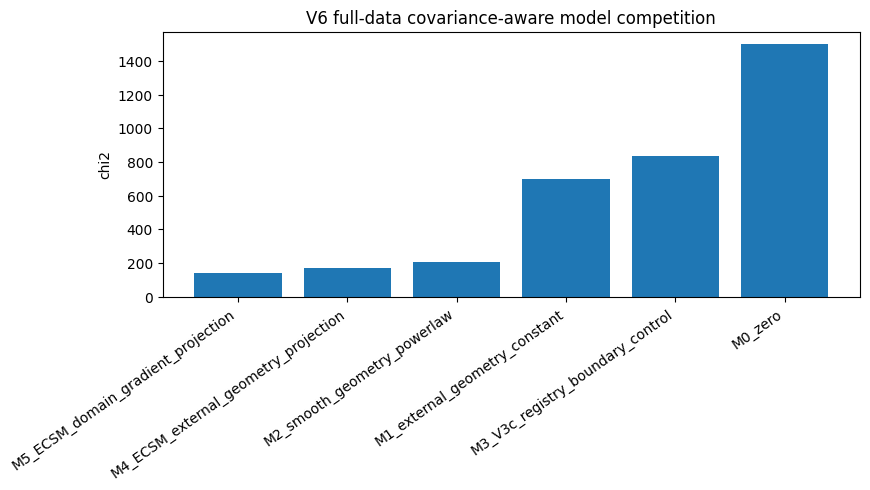

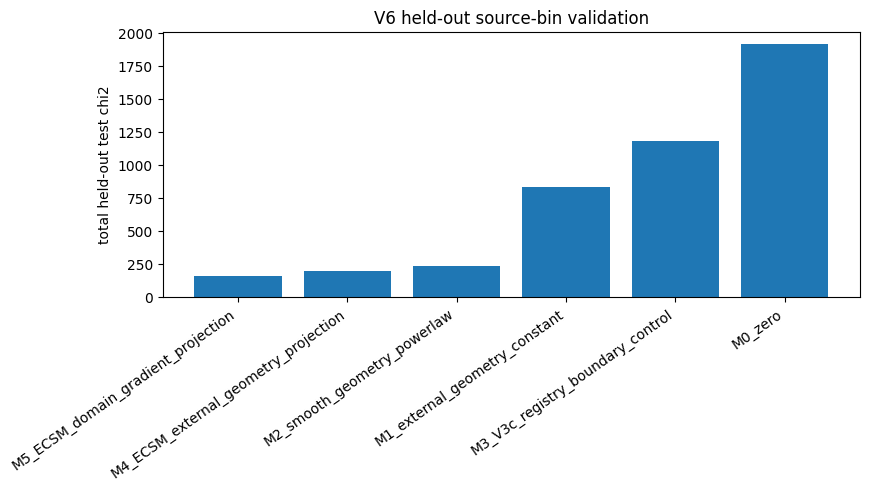

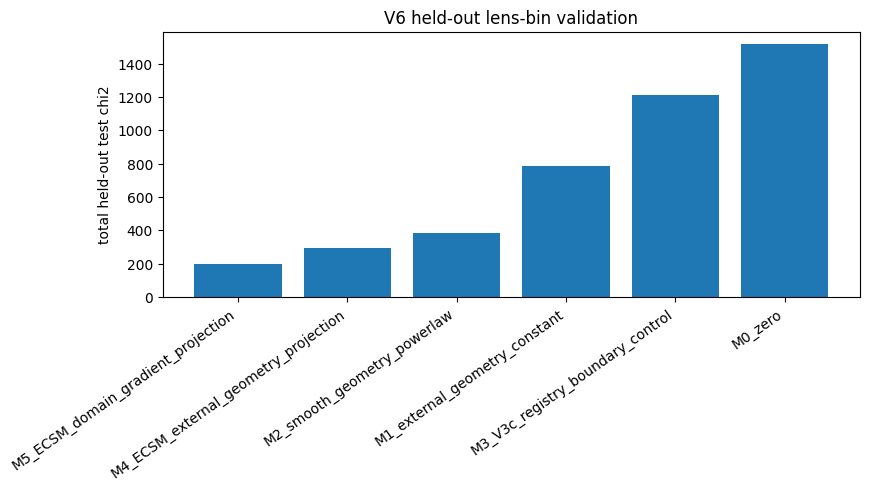

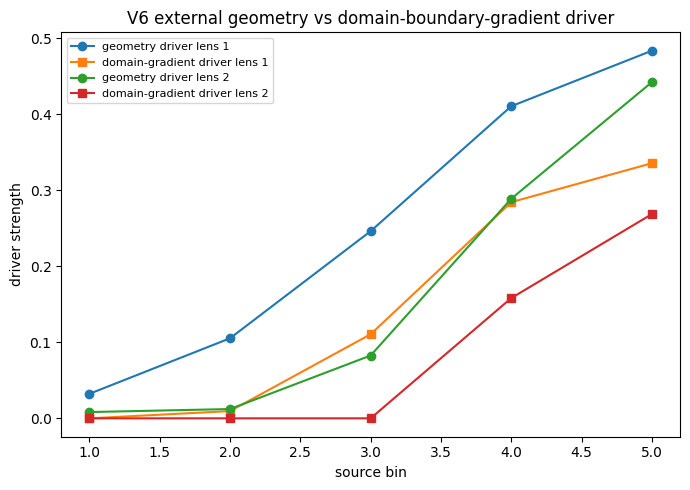

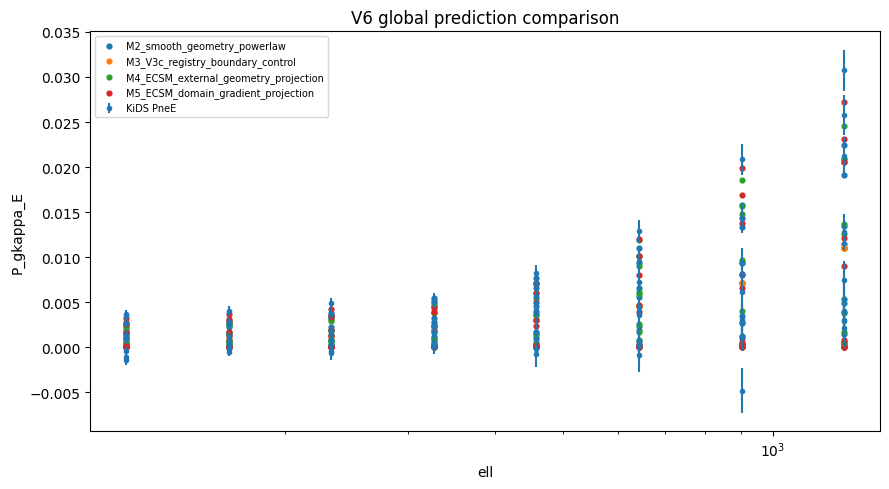

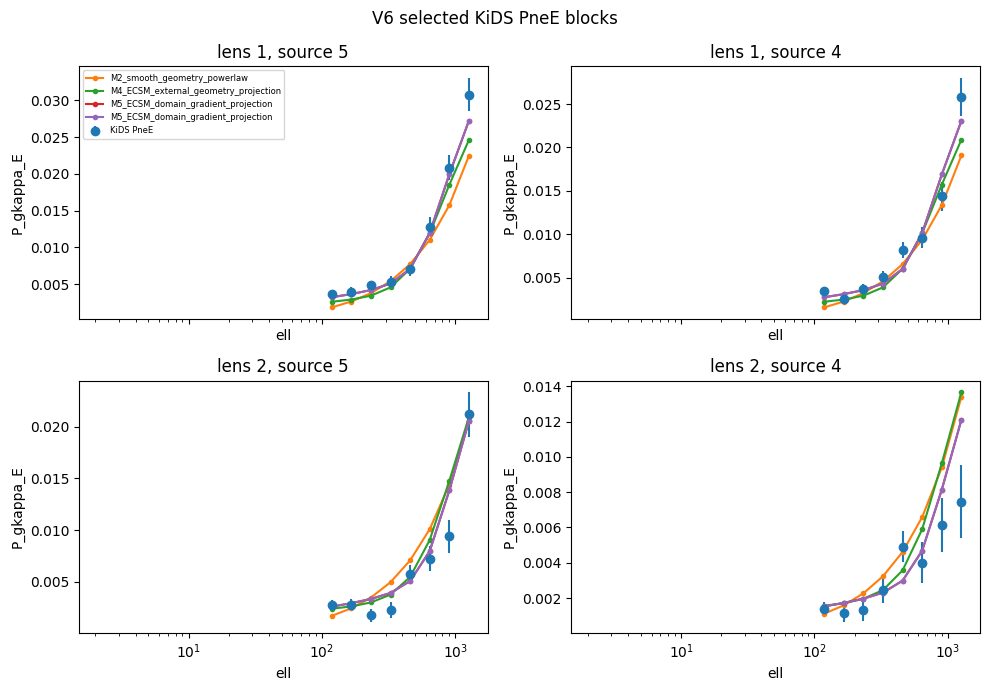

Figures saved in: /content/ecsm_kids_pgk_domain_boundary_gradient_v6_out/figures


In [ ]:
# CELL 10 — PLOTS
print("="*72)
print("CELL 10 — PLOTS")
print("="*72)

plt.figure(figsize=(9,5))
plot_res = res.sort_values("chi2")
plt.bar(plot_res["model"], plot_res["chi2"])
plt.ylabel("chi2")
plt.title("V6 full-data covariance-aware model competition")
plt.xticks(rotation=35, ha="right")
plt.subplots_adjust(bottom=0.35)
plt.savefig(FIG / "v6_model_competition_chi2.png", dpi=180)
plt.show()

for summary, title, fname in [
    (source_summary, "V6 held-out source-bin validation", "v6_heldout_sourcebin_validation.png"),
    (lens_summary, "V6 held-out lens-bin validation", "v6_heldout_lensbin_validation.png"),
]:
    plt.figure(figsize=(9,5))
    s = summary.sort_values("total_test_chi2")
    plt.bar(s["model"], s["total_test_chi2"])
    plt.ylabel("total held-out test chi2")
    plt.title(title)
    plt.xticks(rotation=35, ha="right")
    plt.subplots_adjust(bottom=0.35)
    plt.savefig(FIG / fname, dpi=180)
    plt.show()

plt.figure(figsize=(7,5))
for lb in sorted(vec.lens_bin.unique()):
    sub = geom[geom.lens_bin == lb]
    plt.plot(sub["source_bin"], sub["external_geometry_driver"], marker="o", label=f"geometry driver lens {lb}")
    plt.plot(sub["source_bin"], sub["domain_gradient_driver"], marker="s", label=f"domain-gradient driver lens {lb}")
plt.xlabel("source bin")
plt.ylabel("driver strength")
plt.title("V6 external geometry vs domain-boundary-gradient driver")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "v6_domain_gradient_driver_by_bin.png", dpi=180)
plt.show()

plt.figure(figsize=(9,5))
plt.errorbar(pred_df["ell"], pred_df["Pgk_E"], yerr=pred_df["sigma_diag"], fmt="o", markersize=3, label="KiDS PneE")
for m in ["M2_smooth_geometry_powerlaw", "M3_V3c_registry_boundary_control", "M4_ECSM_external_geometry_projection", "M5_ECSM_domain_gradient_projection"]:
    if m in pred_df.columns:
        plt.scatter(pred_df["ell"], pred_df[m], s=12, label=m)
plt.xscale("log")
plt.xlabel("ell")
plt.ylabel("P_gkappa_E")
plt.title("V6 global prediction comparison")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG / "v6_global_prediction_comparison.png", dpi=180)
plt.show()

best_model = str(res.iloc[0]["model"])
selected_blocks = [(1,5), (1,4), (2,5), (2,4)]
fig, axes = plt.subplots(2, 2, figsize=(10,7), sharex=True)
axes = axes.ravel()
for ax, (lb, sb) in zip(axes, selected_blocks):
    sub = pred_df[(pred_df.lens_bin == lb) & (pred_df.source_bin == sb)].sort_values("ell")
    ax.errorbar(sub["ell"], sub["Pgk_E"], yerr=sub["sigma_diag"], fmt="o", label="KiDS PneE")
    for m in ["M2_smooth_geometry_powerlaw", "M4_ECSM_external_geometry_projection", "M5_ECSM_domain_gradient_projection", best_model]:
        if m in sub.columns:
            ax.plot(sub["ell"], sub[m], marker=".", label=m)
    ax.set_xscale("log")
    ax.set_title(f"lens {lb}, source {sb}")
    ax.set_xlabel("ell")
    ax.set_ylabel("P_gkappa_E")
axes[0].legend(fontsize=6)
plt.suptitle("V6 selected KiDS PneE blocks")
plt.tight_layout()
plt.savefig(FIG / "v6_selected_block_model_comparison.png", dpi=180)
plt.show()

print("Figures saved in:", FIG)


In [ ]:
# CELL 11 — README / SUMMARY REPORT
print("="*72)
print("CELL 11 — README / SUMMARY REPORT")
print("="*72)

def md_table(df):
    try:
        return df.to_markdown(index=False)
    except Exception:
        return df.to_string(index=False)

best = res.iloc[0]
readme = f"""# ECSM_KiDS_Pgk_DomainBoundaryGradient_V6

## Purpose

This notebook tests whether the KiDS-1000 `PneE` galaxy--galaxy lensing bandpower vector is better described when an ECSM-style domain-boundary-gradient term is added to the lens/source projection driver.

The working ECSM chain is:

```text
lens/source geometry
× lens burden proxy
× domain-boundary-gradient proxy
× finite response kernel
→ predicted P_gkappa_E(ell)
```

## Dataset

- Source repository: KiDS-WL `Cat_to_Obs_K1000_P1`
- FITS file: `{FITS_PATH.name}`
- Observable: `PneE`
- Data points: {N}
- Lens bins: {vec.lens_bin.nunique()}
- Source bins: {vec.source_bin.nunique()}
- Ell bins: {vec.ell_bin.nunique()}
- Ell range: {vec.ell.min():.6f} to {vec.ell.max():.6f}
- Covariance shape: {C.shape}
- Covariance method: {cov_method}

## V6 domain-boundary-gradient driver

```text
external_geometry_driver = G_lens_source × lens_burden_norm
domain_gradient_driver = external_geometry_driver × domain_boundary_gradient_chi
domain_boundary_gradient_chi = raw_gradient / (1 + raw_gradient)
```

Lens-specific response scales:

```json
{json.dumps(ellB_by_lens, indent=2)}
```

## Full-data competition

{md_table(res)}

## Held-out source-bin validation

{md_table(source_summary)}

## Held-out lens-bin validation

{md_table(lens_summary)}

## Best full-data model

```json
{json.dumps({"model": str(best["model"]), "family": str(best["family"]), "chi2": float(best["chi2"]), "params": best["params"]}, indent=2, default=str)}
```

## Interpretation guardrail

This is a stronger ECSM projection bridge than V5b because it explicitly includes a domain-boundary-gradient term. It is still not the final first-principles baryonic-mass lensing prediction because the KiDS `PneE` FITS file does not supply physical lens baryonic mass, stellar mass, luminosity, size, or scale-radius information.
"""

print(readme)
(OUT / "README.md").write_text(readme, encoding="utf-8")
print("Saved:", OUT / "README.md")


CELL 11 — README / SUMMARY REPORT
# ECSM_KiDS_Pgk_DomainBoundaryGradient_V6

## Purpose

This notebook tests whether the KiDS-1000 `PneE` galaxy--galaxy lensing bandpower vector is better described when an ECSM-style domain-boundary-gradient term is added to the lens/source projection driver.

The working ECSM chain is:

```text
lens/source geometry
× lens burden proxy
× domain-boundary-gradient proxy
× finite response kernel
→ predicted P_gkappa_E(ell)
```

## Dataset

- Source repository: KiDS-WL `Cat_to_Obs_K1000_P1`
- FITS file: `bp_KIDS1000_BlindC_no_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits`
- Observable: `PneE`
- Data points: 80
- Lens bins: 2
- Source bins: 5
- Ell bins: 8
- Ell range: 118.441992 to 1266.442730
- Covariance shape: (80, 80)
- Covariance method: cholesky

## V6 domain-boundary-gradient driver

```text
external_geometry_driver = G_lens_source × lens_burden_norm
domain_gradient_driver = external_geometry_driver × d

In [ ]:
# CELL 12 — ZIP OUTPUTS AND DOWNLOAD
print("="*72)
print("CELL 12 — ZIP OUTPUTS AND DOWNLOAD")
print("="*72)

zip_path = Path("/content/ECSM_KiDS_Pgk_DomainBoundaryGradient_V6_outputs.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for folder in [TAB, FIG]:
        for f in folder.rglob("*"):
            if f.is_file():
                z.write(f, arcname=str(f.relative_to(OUT)))
    if (OUT / "README.md").exists():
        z.write(OUT / "README.md", arcname="README.md")

print("ZIP ready:", zip_path)
print("Size MB:", zip_path.stat().st_size / 1e6)

try:
    from google.colab import drive, files
    drive.mount("/content/drive", force_remount=False)
    drive_dir = Path("/content/drive/MyDrive/ECSM_KiDS_data")
    drive_dir.mkdir(parents=True, exist_ok=True)
    dest = drive_dir / zip_path.name
    shutil.copy2(zip_path, dest)
    print("Copied to Drive:", dest)
    files.download(str(zip_path))
except Exception as e:
    print("Drive/download helper skipped or unavailable:", repr(e))
    print("Manual download path:", zip_path)


CELL 12 — ZIP OUTPUTS AND DOWNLOAD
ZIP ready: /content/ECSM_KiDS_Pgk_DomainBoundaryGradient_V6_outputs.zip
Size MB: 0.685253
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied to Drive: /content/drive/MyDrive/ECSM_KiDS_data/ECSM_KiDS_Pgk_DomainBoundaryGradient_V6_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>